# Enhancer–promoter distance sweep

For each control we transplant the enhancer at a ladder of distances (10 / 30 / 50 / 100 kb; **50 kb = "distal"**) and read RNA-seq at the gene.


In [5]:
import os, sys
for p in ['.', '..', '../..', '../../..']:
    if os.path.isdir(os.path.join(p, 'fusionseq')): sys.path.insert(0, os.path.abspath(p)); break
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from alphagenome.models import dna_client
from fusionseq import hijack as hj          # build the der at arbitrary distances

pd.set_option('display.max_columns', None)
DATA = next(d for d in ('data', '../data', 'v2/data', '../v2/data', '../../data') if os.path.isdir(d))
tss_centered = pd.read_csv(f'{DATA}/TSS_centered_data.csv')

def _api_key():
    k = os.environ.get('ALPHA_GENOME_API_KEY')
    if k:
        return k
    for p in ('.env', '../.env', '../../.env', '../../../.env'):
        if os.path.exists(p):
            for line in open(p):
                if line.startswith('ALPHA_GENOME_API_KEY='):
                    return line.split('=', 1)[1].strip().strip('"\'')
    raise RuntimeError('ALPHA_GENOME_API_KEY not found')

model = dna_client.create(_api_key())
RNA = dna_client.OutputType.RNA_SEQ
W = 1_048_576

def predict_rna(seq, ontology, strand):
    td = model.predict_sequence(seq, requested_outputs=[RNA], ontology_terms=[ontology]).rna_seq
    vals, meta = np.asarray(td.values), td.metadata
    cols = np.where(meta['strand'].values == strand)[0]
    if len(cols) == 0:
        cols = np.where(meta['strand'].values == '.')[0]
    assert len(cols), f'no RNA-seq track for {ontology}'
    return vals[:, cols].mean(axis=1)

In [6]:
import json, urllib.request

TRANSCRIPTS = {'EVI1 (MECOM)': 'ENST00000264674', 'TAL1': 'ENST00000691006',
               'ETV1': 'ENST00000430479', 'MNX1': 'ENST00000252971'}

def fetch_exons(tx):
    url = f'https://rest.ensembl.org/lookup/id/{tx}?expand=1;content-type=application/json'
    return [(e['start'], e['end']) for e in json.load(urllib.request.urlopen(url, timeout=60))['Exon']]

exons = {g: fetch_exons(tx) for g, tx in TRANSCRIPTS.items()}

In [7]:
# copied from rna_seq_analysis.ipynb (gene close-up: WT vs der), + a helper to build der at any distance
def plot_genezoom(gene, wt, der, tss, strand, exon_list, title, desc, enh=None, pad_kb=10, ymax_fixed=None):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(W) - W // 2) / 1000
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))
    lo, hi = ga - pad_kb, gb + pad_kb
    vis = (x >= lo) & (x <= hi)
    ymax = ymax_fixed if ymax_fixed is not None else max(float(max(wt[vis].max(), der[vis].max())) * 1.15, 1e-4)
    eh = ymax * 0.05

    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(x, wt,  lw=0.9, color='0.55', ls='--', zorder=3)                    # WT  = gray dashed
    ax.plot(x, der, lw=1.0, color='steelblue', zorder=4)                        # der = light blue
    ax.axhline(0, color='0.7', lw=0.5, zorder=2)
    ax.axvline(0, color='0.7', ls=':', lw=0.7, zorder=2)
    for s, e in exon_list:
        a, b = span(s, e)
        ax.add_patch(plt.Rectangle((min(a, b), -1.5 * eh), max(abs(b - a), 0.05), eh,
                                   color='firebrick', lw=0, zorder=5, clip_on=True))
    if enh is not None:
        ex0, ex1 = span(*enh)
        if ex1 >= lo and ex0 <= hi:
            ax.add_patch(plt.Rectangle((max(ex0, lo), -1.5 * eh), min(ex1, hi) - max(ex0, lo), eh,
                                       color='darkorange', lw=0, zorder=6, clip_on=True))
    ax.plot([max(ga, lo), min(gb, hi)], [-2.7 * eh, -2.7 * eh],
            lw=4, color='seagreen', solid_capstyle='butt', zorder=5, clip_on=True)
    ax.text(np.clip((ga + gb) / 2, lo, hi), -2.7 * eh, gene.split()[0],
            ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=7,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='seagreen', edgecolor='none'))
    ax.set_xlim(lo, hi)
    ax.set_ylim(-3.7 * eh, ymax)
    ax.set_ylabel('pred RNA-seq')
    ax.set_xlabel('kb from TSS (transcription orientation: gene body = positive)')
    handles = [Line2D([0], [0], color='steelblue', lw=1.5, label='der'),
               Line2D([0], [0], color='0.55', lw=1.5, ls='--', label='WT'),
               Patch(facecolor='seagreen', label='gene'), Patch(facecolor='firebrick', label='exon')]
    ax.legend(handles=handles, loc='upper right', fontsize=7, frameon=True, framealpha=0.9)
    ax.set_title(f"{title}\n{desc}", fontsize=10, loc='left')
    fig.tight_layout()

def build_der_at(row, d_kb):
    """der with the enhancer transplanted d_kb from the TSS (MNX1 = full block edge-anchored)."""
    anchor = 'edge' if row.driven_gene == 'MNX1' else 'center'
    der, _ = hj.build_der(row.onco_chrom, int(row.onco_tss), row.enh_chrom,
                          int(row.enh_start), int(row.enh_end),
                          d_kb=d_kb, window=W, side='high', anchor=anchor)
    return der

## Distance sweep

For each oncogene, build the der at every distance, predict RNA-seq, and plot the gene close-up. **y is fixed across the distances for each gene**, so the signal visibly decays as the enhancer moves away.

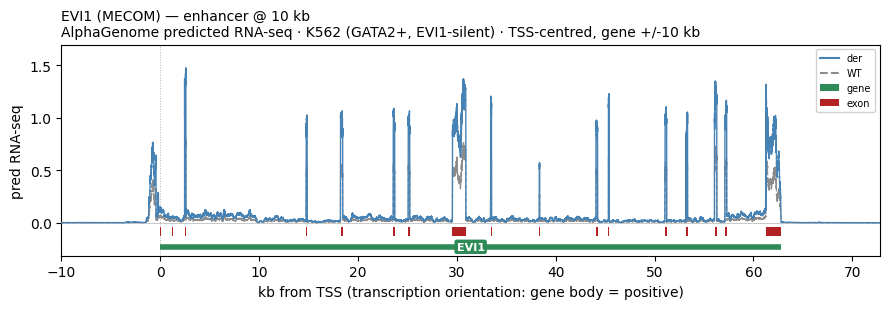

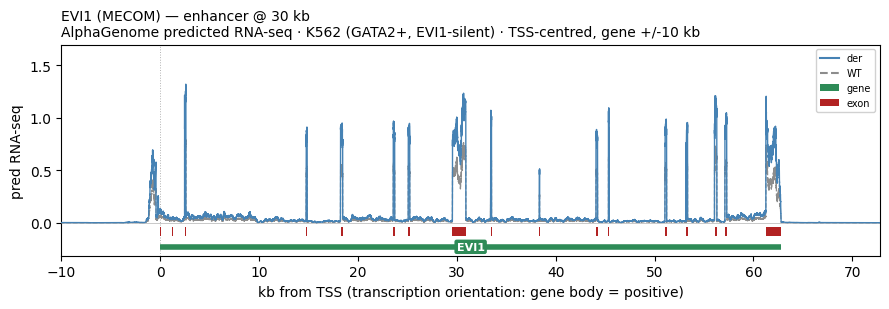

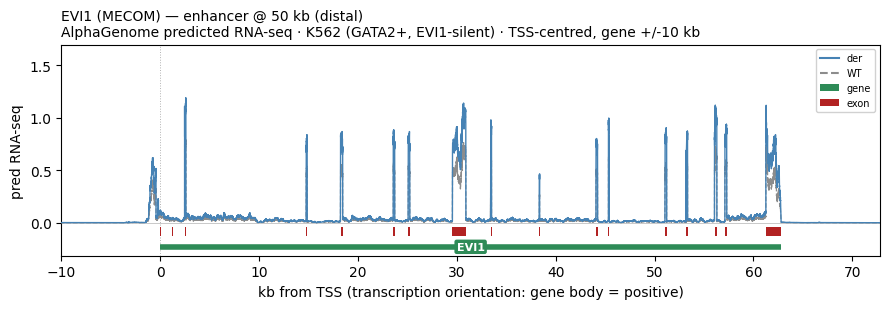

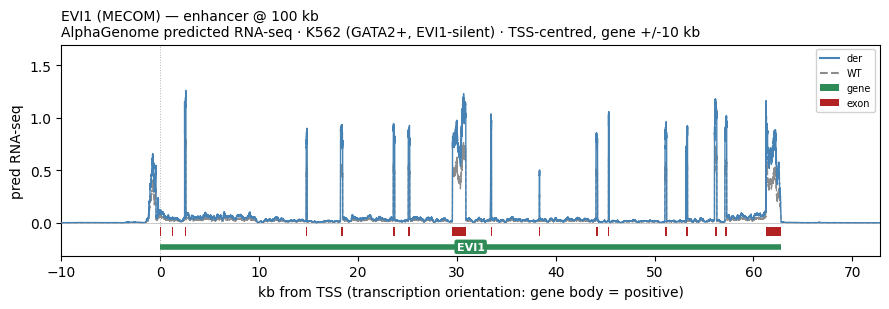

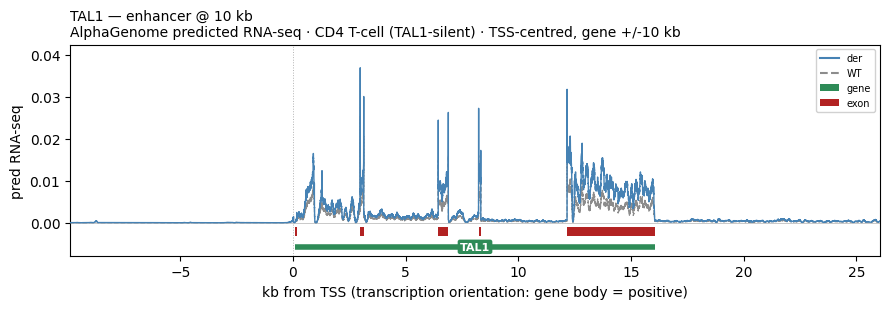

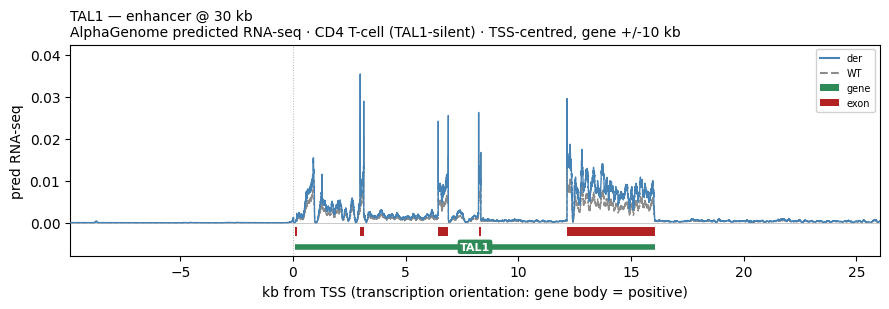

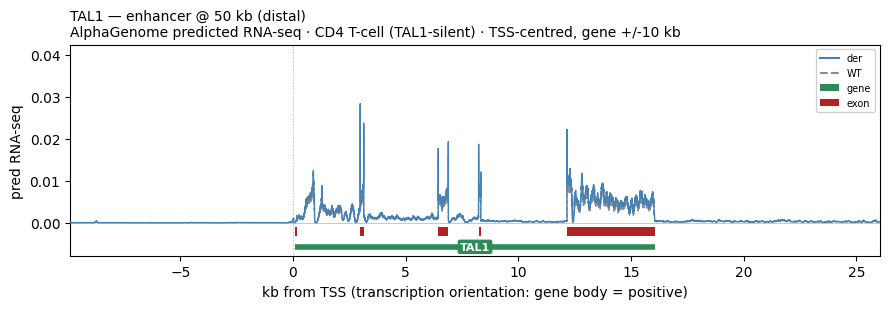

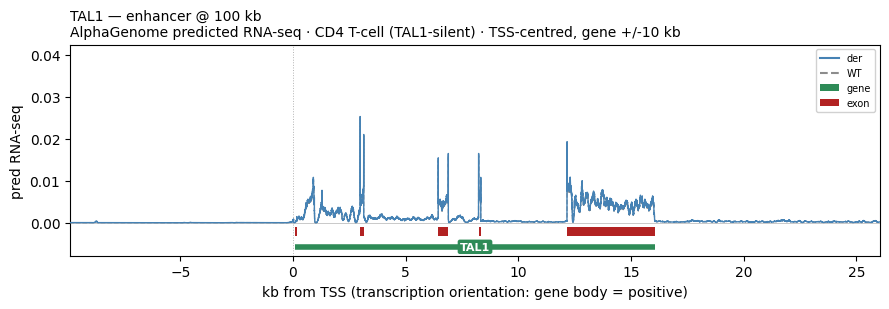

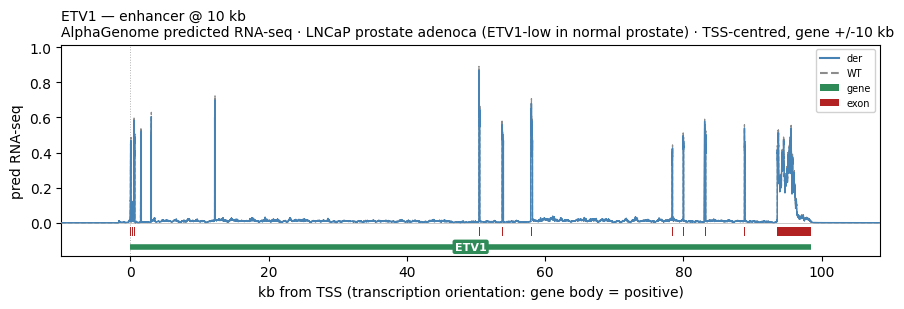

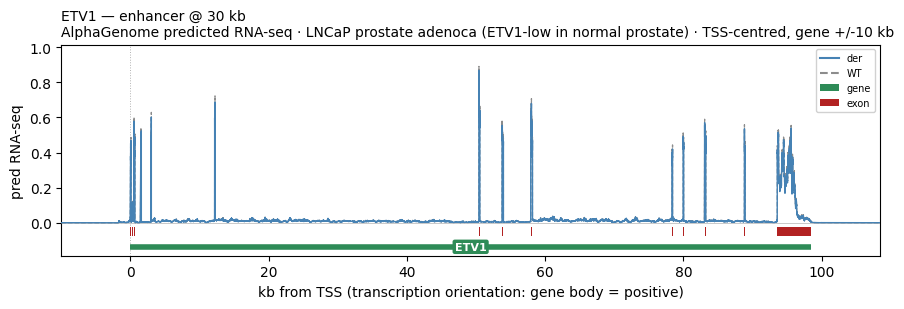

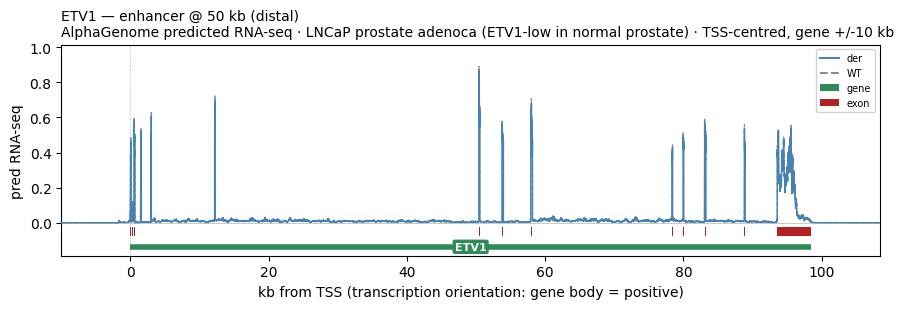

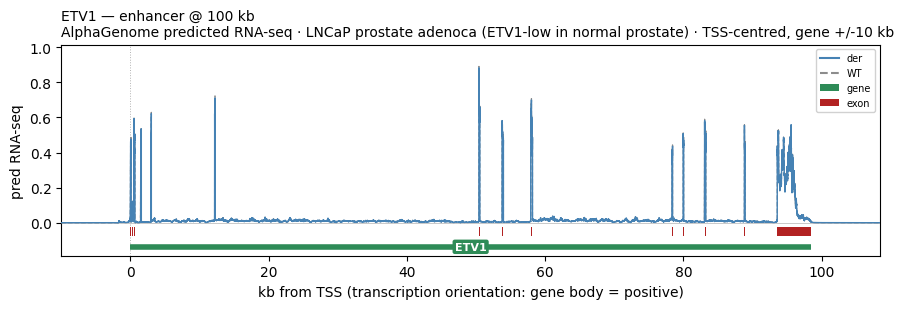

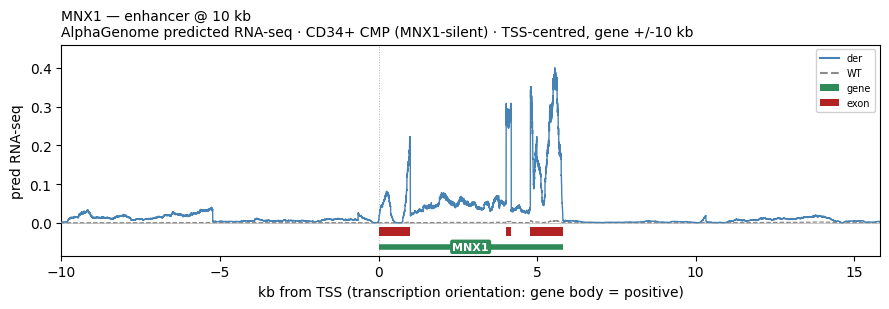

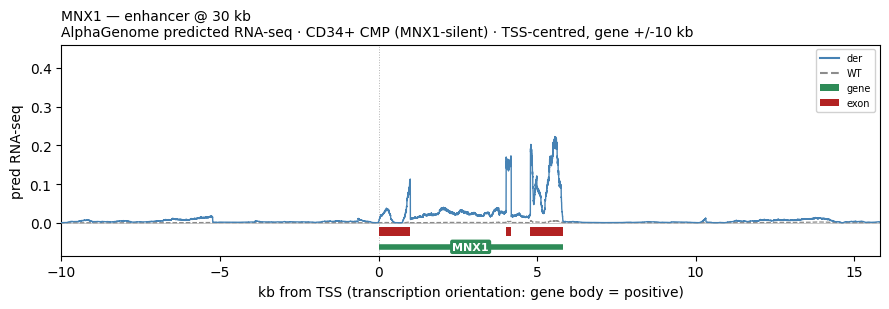

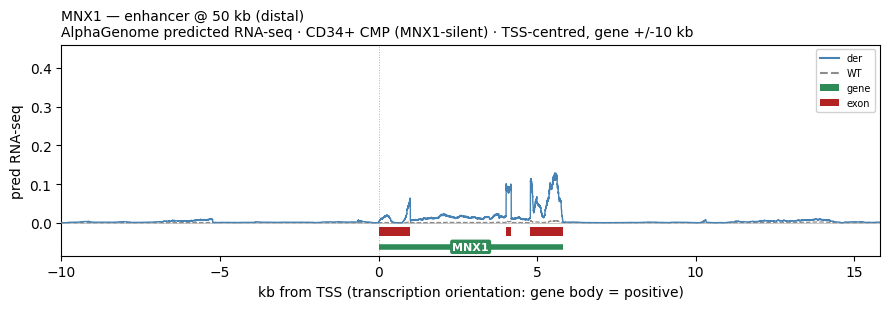

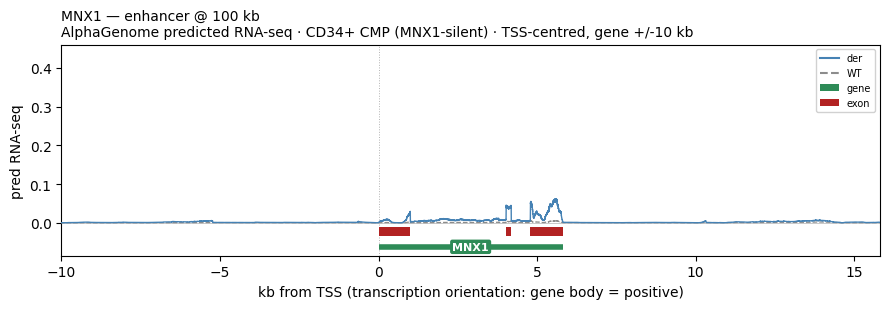

: 

In [ ]:
DISTANCES = [10, 30, 50, 100]    # kb from the TSS; 50 kb = "distal"

genes = tss_centered.dropna(subset=['onco_tss', 'element_len']).drop_duplicates('driven_gene')
for r in genes.itertuples():
    ex = exons[r.driven_gene]
    wt = predict_rna(r.wt_seq, r.ontology, r.strand)
    der_at = {d: predict_rna(build_der_at(r, d), r.ontology, r.strand) for d in DISTANCES}

    flip = -1 if r.strand == '-' else 1                       # fixed y across this gene's distances
    xk = flip * (np.arange(W) - W // 2) / 1000
    sp = sorted((flip * (min(s for s, e in ex) - int(r.onco_tss)) / 1000,
                 flip * (max(e for s, e in ex) - int(r.onco_tss)) / 1000))
    gvis = (xk >= sp[0] - 10) & (xk <= sp[1] + 10)
    ymax = max(float(der_at[d][gvis].max()) for d in DISTANCES) * 1.15

    for d in DISTANCES:
        plot_genezoom(r.driven_gene, wt, der_at[d], int(r.onco_tss), r.strand, ex,
                      f"{r.driven_gene} \u2014 enhancer @ {d} kb" + (" (distal)" if d == 50 else ""),
                      f"AlphaGenome predicted RNA-seq \u00b7 {r.cell_context} \u00b7 TSS-centred, gene +/-10 kb",
                      ymax_fixed=ymax)